In [1]:
import pandas as pad

In [2]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

In [ ]:
df=pad.read_excel('zepto_v1.xlsx')
df.head(5)

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250


In [8]:
df.columns

Index(['Category', 'name', 'mrp', 'discountPercent', 'availableQuantity',
       'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity'],
      dtype='object')

In [9]:
df.describe()

,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,quantity
count,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000
mean,15680.117899,7.617095,4.008574,14192.834941,387.843783,213.270900
std,16088.807618,9.211733,2.203511,13850.726265,678.096509,194.730976
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6000.000000,0.000000,2.000000,5500.000000,100.000000,50.000000
50%,11000.000000,6.000000,5.000000,10400.000000,225.000000,186.000000
75%,20000.000000,10.000000,6.000000,18400.000000,450.000000,340.000000
max,260000.000000,51.000000,6.000000,139900.000000,10000.000000,1500.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Category                3732 non-null   object
 1   name                    3732 non-null   object
 2   mrp                     3732 non-null   int64 
 3   discountPercent         3732 non-null   int64 
 4   availableQuantity       3732 non-null   int64 
 5   discountedSellingPrice  3732 non-null   int64 
 6   weightInGms             3732 non-null   int64 
 7   outOfStock              3732 non-null   bool  
 8   quantity                3732 non-null   int64 
dtypes: bool(1), int64(6), object(2)
memory usage: 237.0+ KB


In [12]:
df.isnull().sum()

Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
dtype: int64

In [14]:
df.duplicated().sum()

2

In [15]:
df.drop_duplicates()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250
...,...,...,...,...,...,...,...,...,...
3727,Health & Hygiene,Stayfree Secure Dry Cover Extra Large Sanitary...,4200,2,0,4100,406,True,7
3728,Health & Hygiene,Dabur Honitus Herbal Cough Remedy Ayurvedic Syrup,10500,15,0,8900,100,True,100
3729,Health & Hygiene,Whisper Bindazzz Night Sanitary Pads XL Plus,18500,0,0,18500,870,True,15
3730,Health & Hygiene,Fine Life Cotton Balls,6000,0,0,6000,50,True,50


In [17]:
df.shape

(3732, 9)

In [18]:
df["discountAmount"] = df["mrp"] - df["discountedSellingPrice"]

df["price_per_kg"] = df["discountedSellingPrice"] / (df["weightInGms"] / 1000)

In [20]:
df["discountAmount"]
df["price_per_kg"]

0         2100.000000
1         3500.000000
2        74137.931034
3        17000.000000
4         4800.000000
            ...      
3727     10098.522167
3728     89000.000000
3729     21264.367816
3730    120000.000000
3731     50000.000000
Name: price_per_kg, Length: 3732, dtype: float64

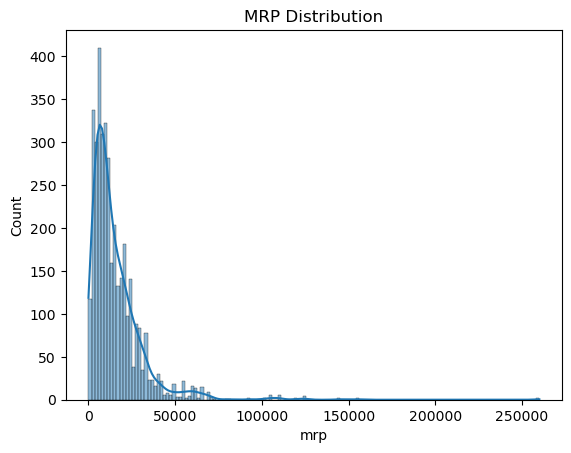

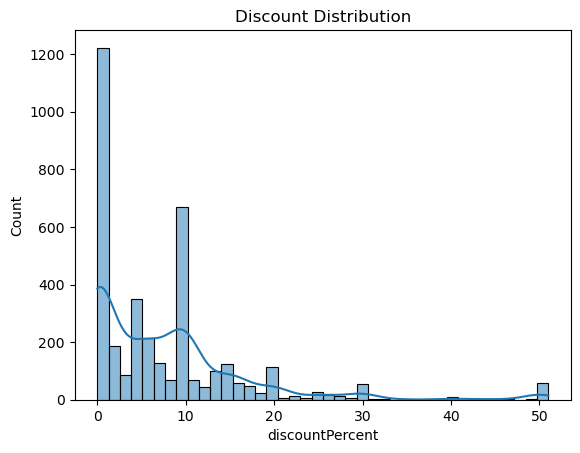

In [21]:
# Distribution of MRP
sns.histplot(df["mrp"], kde=True)
plt.title("MRP Distribution")
plt.show()

# Discount %
sns.histplot(df["discountPercent"], kde=True)
plt.title("Discount Distribution")
plt.show()

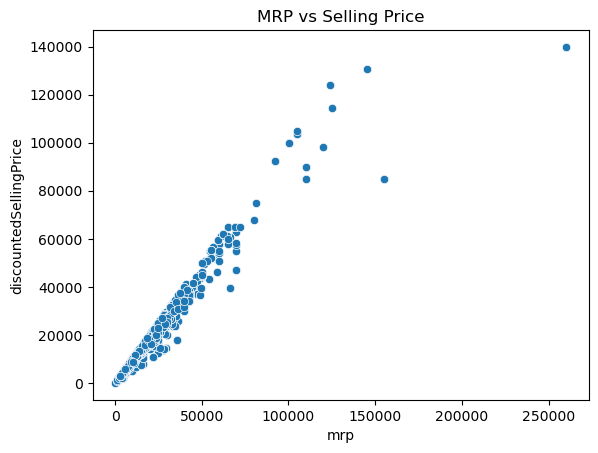

In [22]:
# MRP vs Selling Price
sns.scatterplot(x="mrp", y="discountedSellingPrice", data=df)
plt.title("MRP vs Selling Price")
plt.show()

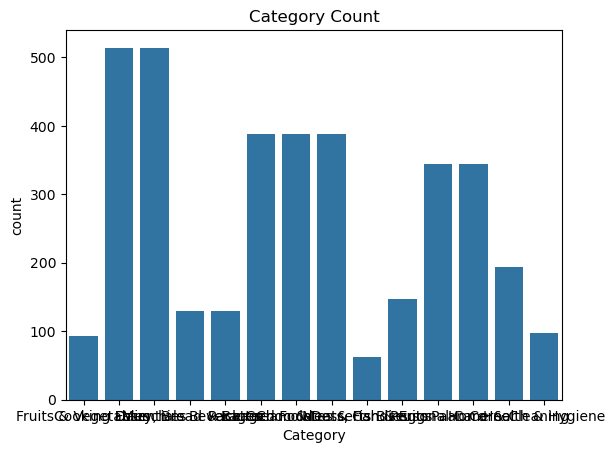

In [24]:
# Count of products by category
sns.countplot(x="Category", data=df)
plt.title("Category Count")
plt.show()

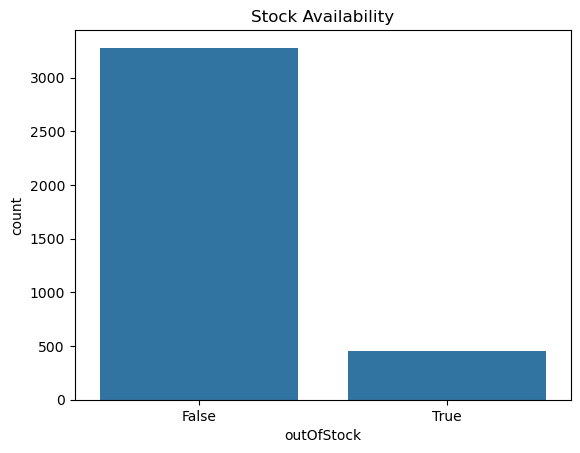

In [25]:
# Out of stock check
sns.countplot(x="outOfStock", data=df)
plt.title("Stock Availability")
plt.show()

In [27]:

# Revenue (important for business)
df["revenue"] = df["discountedSellingPrice"] * df["quantity"]
df.sort_values(by="revenue", ascending=False)

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,discountAmount,price_per_kg,revenue
877,Munchies,Praakritik Natural Desi Gir Cow A2 Ghee,145000,10,6,130500,540,False,540,14500,2.416667e+05,70470000
363,Cooking Essentials,Praakritik Natural Desi Gir Cow A2 Ghee,145000,10,6,130500,540,False,540,14500,2.416667e+05,70470000
2931,Personal Care,Dove Daily Shine Shampoo,64500,5,3,61200,650,False,650,3300,9.415385e+04,39780000
3275,Paan Corner,Dove Daily Shine Shampoo,64500,5,3,61200,650,False,650,3300,9.415385e+04,39780000
2192,Chocolates & Candies,Whiskas Kitten (2-12 months) Dry Cat Food Food...,38500,9,5,34700,1100,False,1100,3800,3.154545e+04,38170000
...,...,...,...,...,...,...,...,...,...,...,...,...
3606,Home & Cleaning,Cherry Blossom Liquid Shoe Polish Neutral,0,0,1,0,75,False,75,0,0.000000e+00,0
3184,Paan Corner,Maybelline New York Colossal Kajal Black,14900,0,2,14900,0,False,0,0,inf,0
3273,Paan Corner,Maybelline New York Colossal Kajal Super Black,30000,8,3,27500,0,False,0,2500,inf,0
2840,Personal Care,Maybelline New York Colossal Kajal Black,14900,0,2,14900,0,False,0,0,inf,0


In [28]:
# Stock value
df["stock_value"] = df["availableQuantity"] * df["discountedSellingPrice"]

In [29]:
# Which products have highest discount?
df.sort_values(by="discountPercent", ascending=False)

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,discountAmount,price_per_kg,revenue,stock_value
2608,Biscuits,Dukes Waffy Chocolate Wafers,4500,51,4,2200,60,False,75,2300,36666.666667,165000,8800
2615,Biscuits,Dukes Waffy Orange Wafers,4500,51,5,2200,60,False,75,2300,36666.666667,165000,11000
2619,Biscuits,Dukes Waffy Strawberry Wafers,4500,51,2,2200,60,False,75,2300,36666.666667,165000,4400
2219,Chocolates & Candies,Chef's Basket Durum Wheat Fusilli Pasta,16000,50,6,8000,500,False,500,8000,16000.000000,4000000,48000
1431,Packaged Food,Chef's Basket Durum Wheat Elbow Pasta,16000,50,6,8000,500,False,500,8000,16000.000000,4000000,48000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2723,Biscuits,Britannia Marie Gold Biscuit,2800,0,0,2800,200,True,200,0,14000.000000,560000,0
2722,Biscuits,Britannia Milk Bikis Milky Sandwich,2500,0,0,2500,120,True,120,0,20833.333333,300000,0
1349,Beverages,Yoga Bar Peanut Butter Dark Chocolate Jar,24900,0,4,24900,400,False,400,0,62250.000000,9960000,99600
2719,Biscuits,Britannia Milk Bikis Cream Biscuit,4500,0,0,4500,200,True,200,0,22500.000000,900000,0


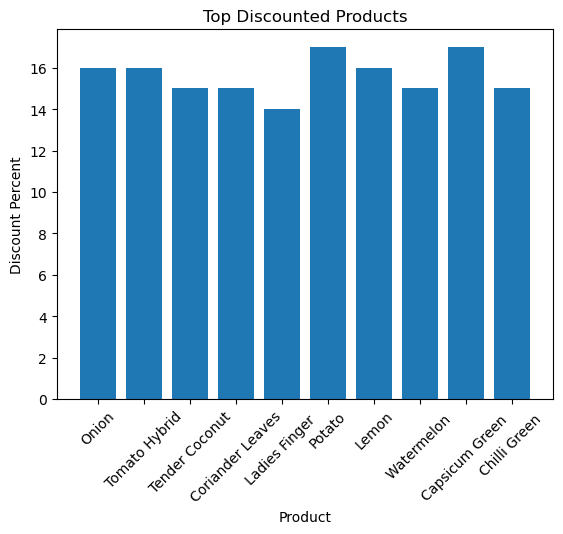

In [ ]:


top_n = df.head(10)  # top 10 products

plt.figure()
plt.bar(top_n["name"], top_n["discountPercent"])
plt.xticks(rotation=45)
plt.xlabel("Product")
plt.ylabel("Discount Percent")
plt.title("Top Discounted Products")
plt.show()

In [31]:
#    Low stock alert (important in real companies)
low_stock = df[df["availableQuantity"] < 5].head(5)
print(low_stock)

              Category              name   mrp  discountPercent  \
0  Fruits & Vegetables             Onion  2500               16   
1  Fruits & Vegetables     Tomato Hybrid  4200               16   
2  Fruits & Vegetables    Tender Coconut  5100               15   
3  Fruits & Vegetables  Coriander Leaves  2000               15   
4  Fruits & Vegetables    Ladies Finger   1400               14   

   availableQuantity  discountedSellingPrice  weightInGms  outOfStock  \
0                  3                    2100         1000       False   
1                  3                    3500         1000       False   
2                  3                    4300           58       False   
3                  3                    1700          100       False   
4                  3                    1200          250       False   

   quantity  discountAmount  price_per_kg  revenue  stock_value  
0         1             400   2100.000000     2100         6300  
1         1             70

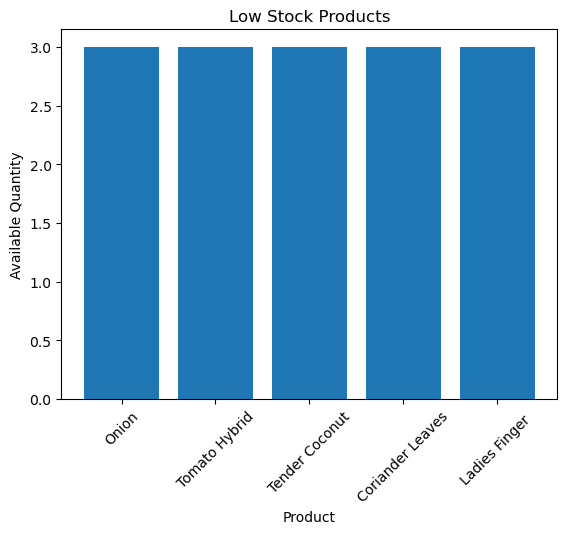

In [48]:


plt.figure()
plt.bar(low_stock["name"], low_stock["availableQuantity"])
plt.xlabel("Product")
plt.ylabel("Available Quantity")
plt.title("Low Stock Products")
plt.xticks(rotation=45)
plt.show()

In [49]:
# Out of stock products
df[df["outOfStock"] == True].sort_values(by='stock_value',ascending=True).head(5)

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,discountAmount,price_per_kg,revenue,stock_value
87,Fruits & Vegetables,Carrot,1300,15,0,1100,250,True,200,200,4400.000000,220000,0
2526,Chocolates & Candies,Sunfeast Pasta Treat Pack of Tomato Cheese,2800,17,0,2300,65,True,65,500,35384.615385,149500,0
2525,Chocolates & Candies,Zorabian Chicken Kheema Parathas,19000,0,0,19000,300,True,300,0,63333.333333,5700000,0
2524,Chocolates & Candies,Dabur Hommade - Imli Sauce Saunth,2000,10,0,1800,100,True,100,200,18000.000000,180000,0
2523,Chocolates & Candies,Chef's Basket Durum Wheat Penne Pasta,16000,50,0,8000,500,True,500,8000,16000.000000,4000000,0


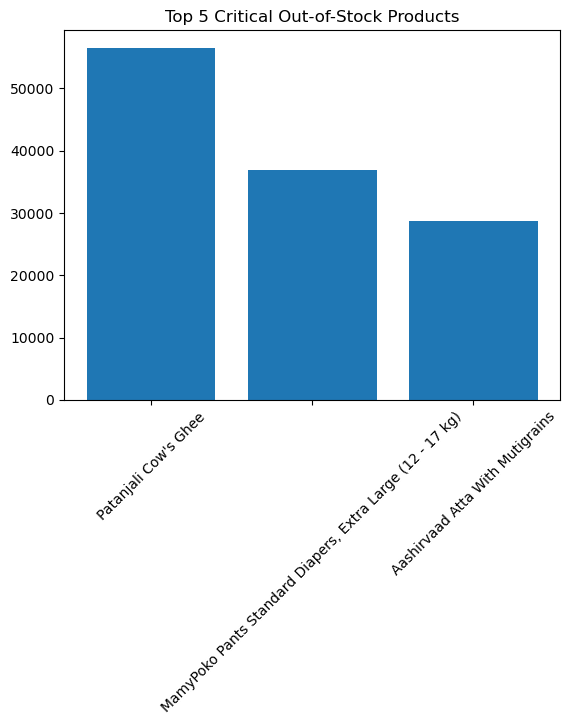

In [61]:
top_out = df[df["outOfStock"] == True] \
            .sort_values(by="discountedSellingPrice", ascending=False) \
            .head(5)

plt.figure()
plt.bar(top_out["name"], top_out["discountedSellingPrice"])
plt.xticks(rotation=45)
plt.title("Top 5 Critical Out-of-Stock Products")
plt.show()

In [42]:
# Category-wise revenue
df.groupby("Category")["revenue"].sum()

Category
Beverages                 333048300
Biscuits                  179207600
Chocolates & Candies     1734991700
Cooking Essentials       1361622600
Dairy, Bread & Batter     333048300
Fruits & Vegetables        44099700
Health & Hygiene          149611700
Home & Cleaning           367834300
Ice Cream & Desserts     1734991700
Meats, Fish & Eggs        369397600
Munchies                 1361622600
Paan Corner              1261482500
Packaged Food            1734991700
Personal Care            1261482500
Name: revenue, dtype: int64

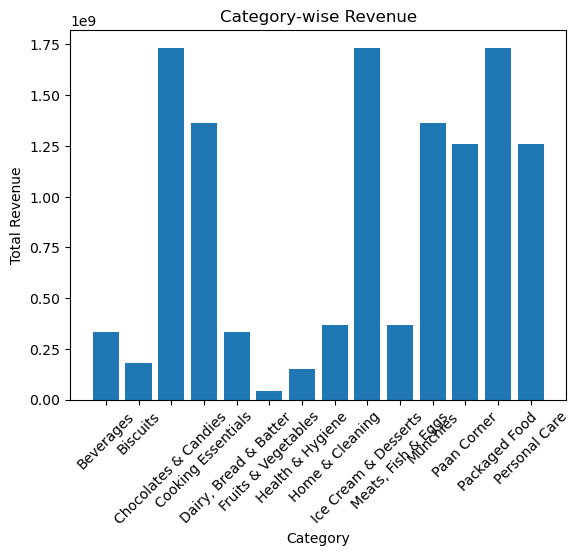

In [62]:
import matplotlib.pyplot as plt

category_revenue = df.groupby("Category")["revenue"].sum()

plt.figure()
plt.bar(category_revenue.index, category_revenue.values)
plt.xticks(rotation=45)
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.title("Category-wise Revenue")
plt.show()

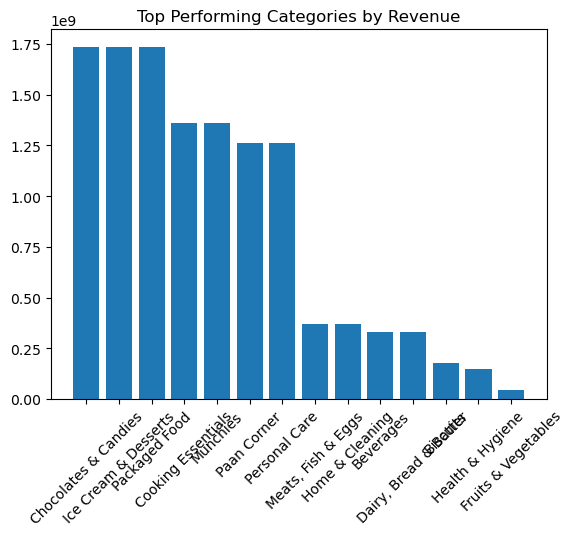

In [63]:
category_revenue = df.groupby("Category")["revenue"].sum() \
                     .sort_values(ascending=False)

plt.figure()
plt.bar(category_revenue.index, category_revenue.values)
plt.xticks(rotation=45)
plt.title("Top Performing Categories by Revenue")
plt.show()

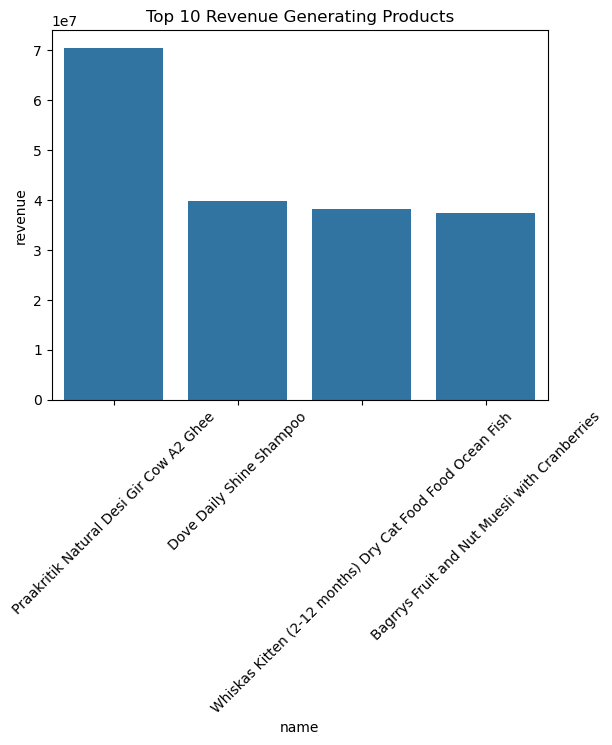

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

top_products = df.sort_values(by="revenue", ascending=False).head(10)

plt.figure()
sns.barplot(x="name", y="revenue", data=top_products)
plt.xticks(rotation=45)
plt.title("Top 10 Revenue Generating Products")
plt.show()

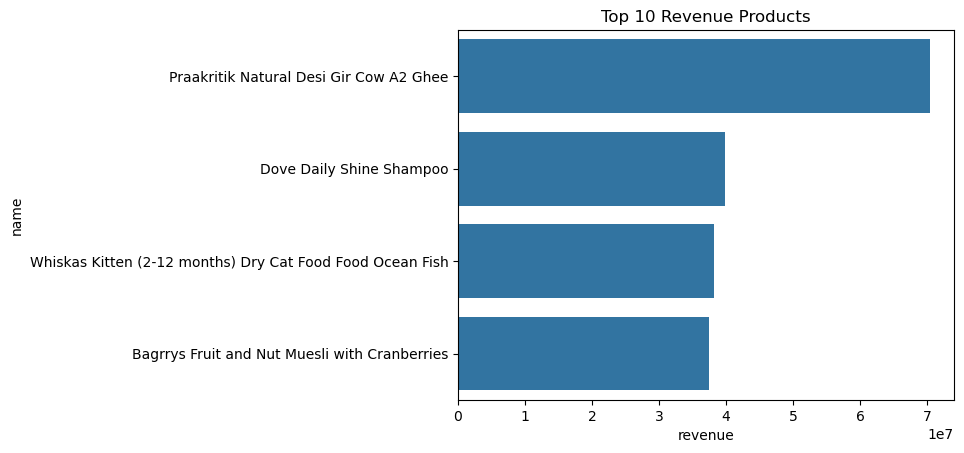

In [65]:
top_products = df.sort_values(by="revenue", ascending=False).head(10)

plt.figure()
sns.barplot(y="name", x="revenue", data=top_products)
plt.title("Top 10 Revenue Products")
plt.show()

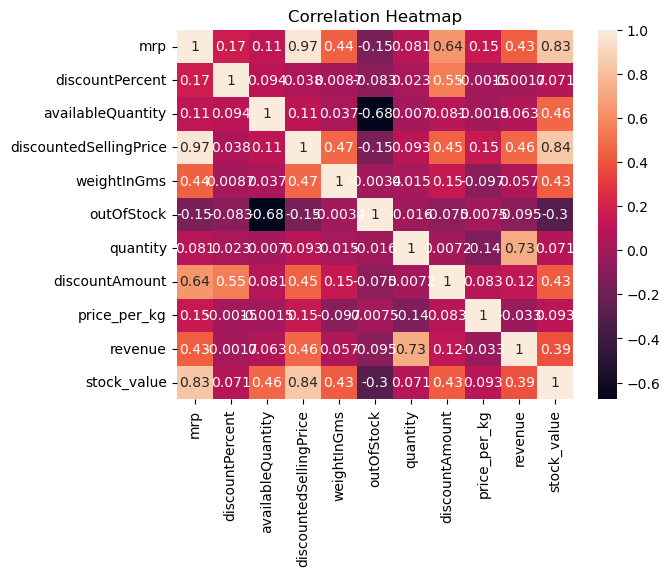

In [45]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [67]:
total_revenue = df["revenue"].sum()
avg_discount = df["discountPercent"].mean()
out_of_stock_count = df["outOfStock"].sum()

In [68]:
df.groupby("Category").agg({
    "revenue": "sum",
    "discountPercent": "mean",
    "quantity": "sum"
})

,revenue,discountPercent,quantity
Category,,,
Beverages,333048300,7.155039,28843
Biscuits,179207600,8.244898,26009
Chocolates & Candies,1734991700,8.324742,103490
Cooking Essentials,1361622600,7.163424,106489
"Dairy, Bread & Batter",333048300,7.155039,28843
Fruits & Vegetables,44099700,15.462366,16030
Health & Hygiene,149611700,8.051546,8054
Home & Cleaning,367834300,5.675258,26109
Ice Cream & Desserts,1734991700,8.324742,103490


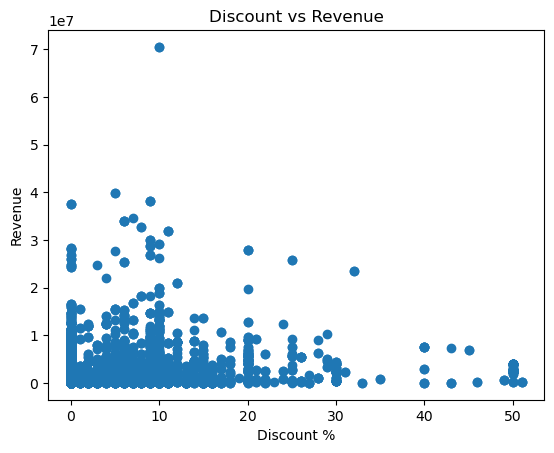

In [69]:


plt.figure()
plt.scatter(df["discountPercent"], df["revenue"])
plt.xlabel("Discount %")
plt.ylabel("Revenue")
plt.title("Discount vs Revenue")
plt.show()

In [70]:
df["inventory_risk"] = df["availableQuantity"].apply(
    lambda x: "High Risk" if x < 5 else "Safe"
)

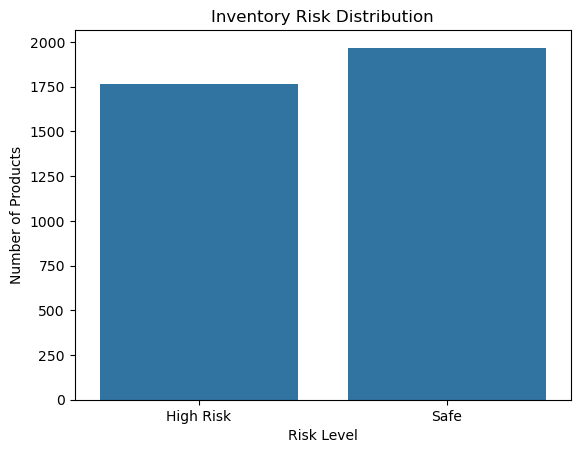

In [71]:

sns.countplot(x="inventory_risk", data=df)
plt.title("Inventory Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Products")
plt.show()

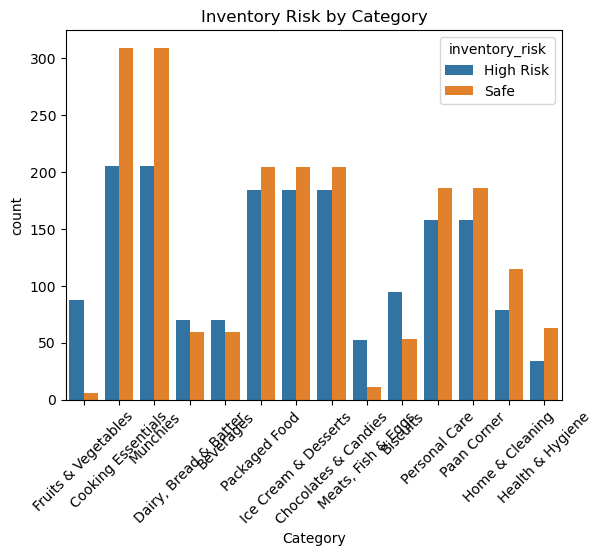

In [73]:
sns.countplot(x="Category", hue="inventory_risk", data=df)
plt.title("Inventory Risk by Category")
plt.xticks(rotation=45)
plt.show()

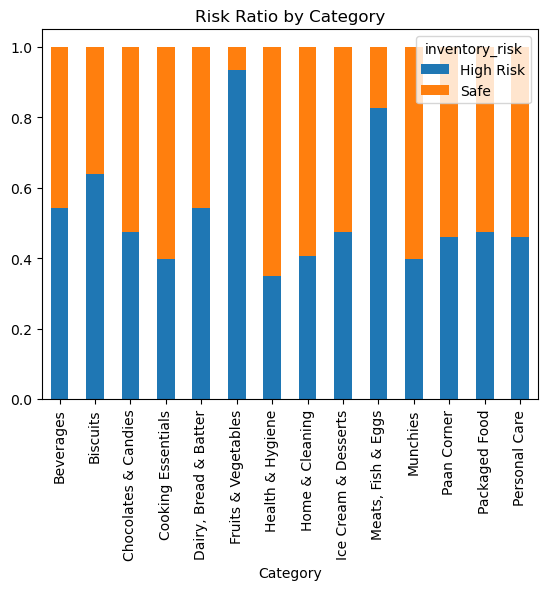

In [74]:
risk_ratio = df.groupby("Category")["inventory_risk"].value_counts(normalize=True).unstack()

risk_ratio.plot(kind="bar", stacked=True)
plt.title("Risk Ratio by Category")
plt.show()

In [76]:
def segment(row):
    if row["revenue"] > df["revenue"].median():
        return "High Value"
    else:
        return "Low Value"

df["segment"] = df.apply(segment, axis=1)

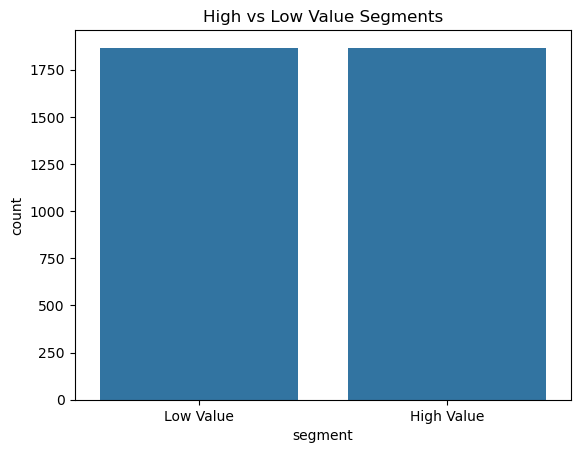

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="segment", data=df)
plt.title("High vs Low Value Segments")
plt.show()

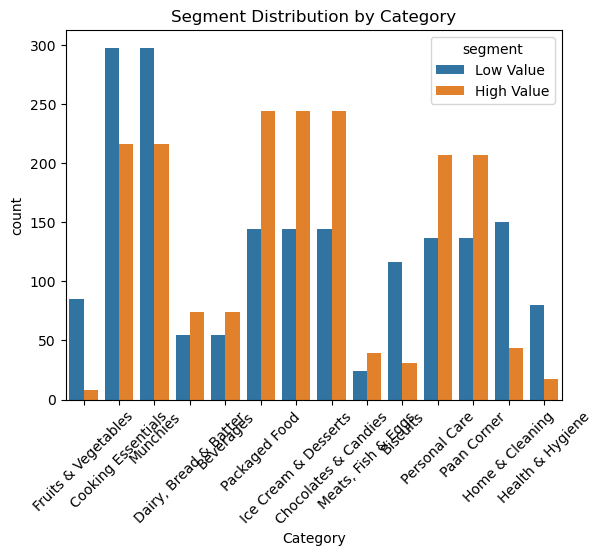

In [78]:
sns.countplot(x="Category", hue="segment", data=df)
plt.xticks(rotation=45)
plt.title("Segment Distribution by Category")
plt.show()

In [82]:
dead_stock = df[(df["quantity"] == 0) & (df["availableQuantity"] > 0)]

In [83]:
dead_stock_count = dead_stock.shape[0]
total_products = df.shape[0]

print(f"Dead Stock: {dead_stock_count} / {total_products}")

Dead Stock: 4 / 3732


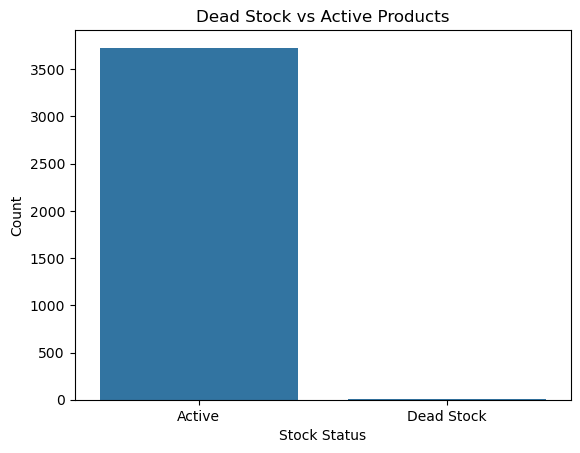

In [84]:
df["dead_stock_flag"] = ((df["quantity"] == 0) & (df["availableQuantity"] > 0))

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["dead_stock_flag"].map({True: "Dead Stock", False: "Active"}))
plt.title("Dead Stock vs Active Products")
plt.xlabel("Stock Status")
plt.ylabel("Count")
plt.show()

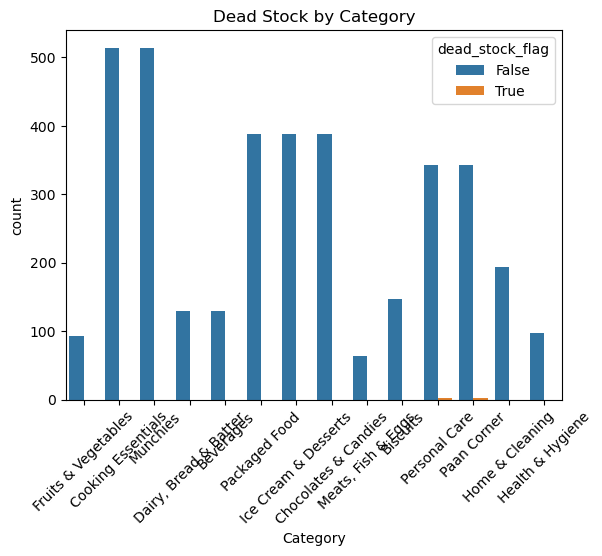

In [86]:
sns.countplot(x="Category", hue=df["dead_stock_flag"], data=df)
plt.xticks(rotation=45)
plt.title("Dead Stock by Category")
plt.show()

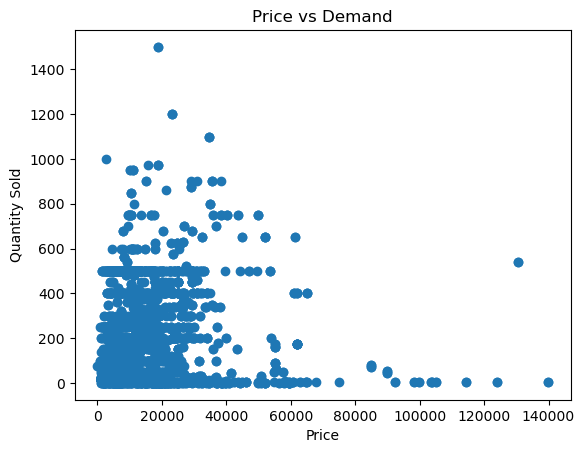

In [88]:
plt.figure()
plt.scatter(df["discountedSellingPrice"], df["quantity"])
plt.xlabel("Price")
plt.ylabel("Quantity Sold")
plt.title("Price vs Demand")
plt.show()

In [89]:
df[df["outOfStock"] == True]["revenue"].sum()

891494550

In [90]:
df["profit_estimate"] = df["mrp"] - df["discountedSellingPrice"]

df.groupby("Category")["profit_estimate"].sum()

Category
Beverages                193200
Biscuits                  98640
Chocolates & Candies     568400
Cooking Essentials       807400
Dairy, Bread & Batter    193200
Fruits & Vegetables       66700
Health & Hygiene         129200
Home & Cleaning          207700
Ice Cream & Desserts     568400
Meats, Fish & Eggs       146100
Munchies                 807400
Paan Corner              597900
Packaged Food            568400
Personal Care            597900
Name: profit_estimate, dtype: int64

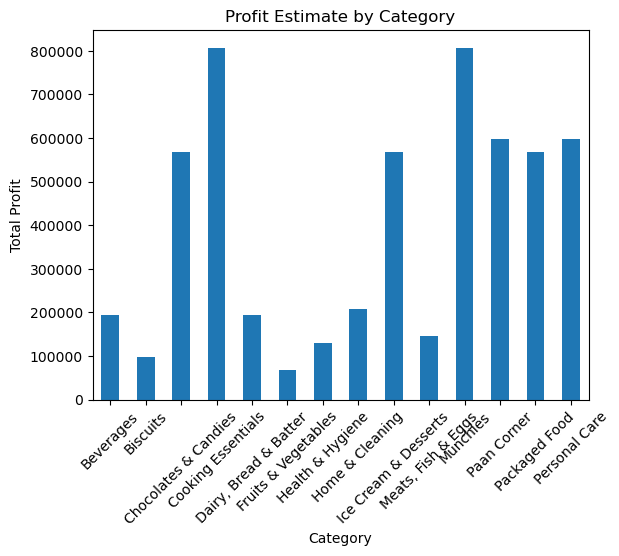

In [ ]:


profit_by_category = df.groupby("Category")["profit_estimate"].sum()

profit_by_category.plot(kind="bar")
plt.title("Profit Estimate by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

In [100]:
df["avg_order_value"] = df["revenue"] / df["quantity"]

worked on a zepto EDA project where I analyzed product-level sales, discounts, and inventory data. I created KPIs like revenue and profit estimates, identified top-performing products, analyzed discount effectiveness, and detected inventory risks like low stock and out-of-stock items. Based on the analysis, I provided actionable recommendations to improve revenue and inventory management.